# Precipitation Prediction Using Machine Learning

## Predicting Weather Precipitation Type from Atmospheric Conditions
---
### Author: Arvin Kelly Butiong
---

## Project Overview

Weather prediction plays a crucial role in industries such as agriculture,
aviation, logistics, and disaster preparedness.

This project uses historical weather data to build machine learning models
capable of predicting **precipitation type** (rain, snow, or none) based on
environmental conditions.

### Tools Used

• Python  
• Pandas  
• NumPy  
• Matplotlib  
• Seaborn  
• Scikit-learn

The analysis includes:

• Data cleaning and preprocessing  
• Feature engineering  
• Exploratory data analysis  
• Machine learning model training  
• Model comparison and evaluation  
• Feature importance interpretation  

The goal is to determine **which atmospheric variables most strongly influence precipitation events.**

## Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

## Load Dataset

The dataset contains historical weather observations including
temperature, humidity, wind speed, pressure, and visibility.

The target variable for prediction is **Precip Type**.

In [2]:
df = pd.read_csv("weatherHistory.csv")

df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


## Dataset Overview

In [3]:
df.shape

(96453, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


In [5]:
df.describe()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.0,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,0.0,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,0.0,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,0.0,1011.900000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,0.0,1016.450000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,0.0,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000


## Handling Missing Values

In [6]:
df.isnull().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

In [7]:
df["Precip Type"].fillna("none", inplace=True)

## Removing Duplicate Records

In [8]:
print("Before:", df.shape)

df.drop_duplicates(inplace=True)

print("After:", df.shape)

Before: (96453, 12)
After: (96429, 12)


## Feature Engineering from Date

Time-based features can help identify seasonal or hourly weather patterns.

In [9]:
df["Formatted Date"] = pd.to_datetime(df["Formatted Date"], utc=True)

df["year"] = df["Formatted Date"].dt.year
df["month"] = df["Formatted Date"].dt.month
df["day"] = df["Formatted Date"].dt.day
df["hour"] = df["Formatted Date"].dt.hour

## Removing Text Columns

Text descriptions are not useful for numerical machine learning models.

In [10]:
df = df.drop(columns=[
    "Formatted Date",
    "Daily Summary",
    "Summary"
], errors="ignore")

df = df.dropna()

df.head()

,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),year,month,day,hour
0,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,2006,3,31,22
1,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,2006,3,31,23
2,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,2006,4,1,0
3,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,2006,4,1,1
4,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,2006,4,1,2


## Removing Invalid Pressure Values

Pressure values equal to zero are unrealistic in atmospheric data.

In [11]:
df = df[df["Pressure (millibars)"] > 0]

## Removing Constant Features

In [26]:
df.drop("Loud Cover", axis=1, inplace=True)

## Distribution of Weather Variables

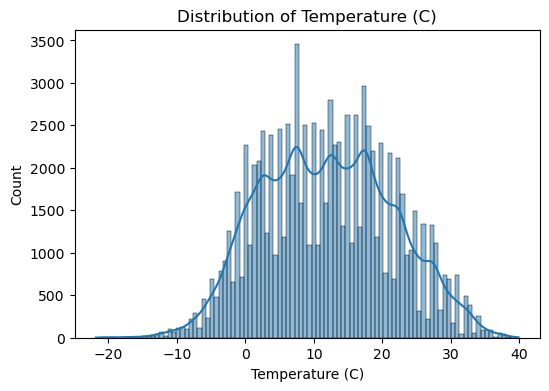

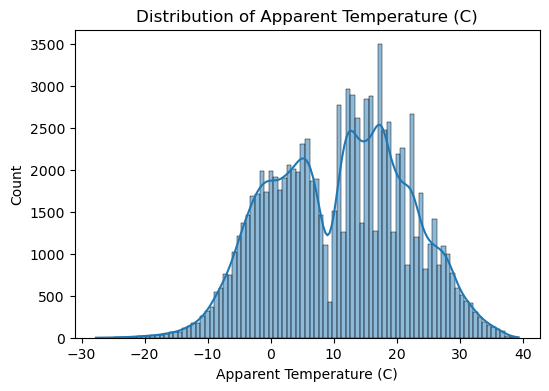

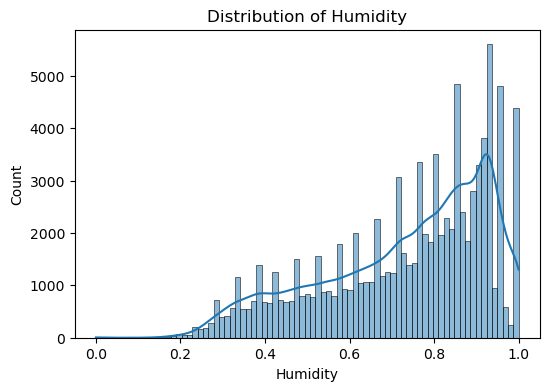

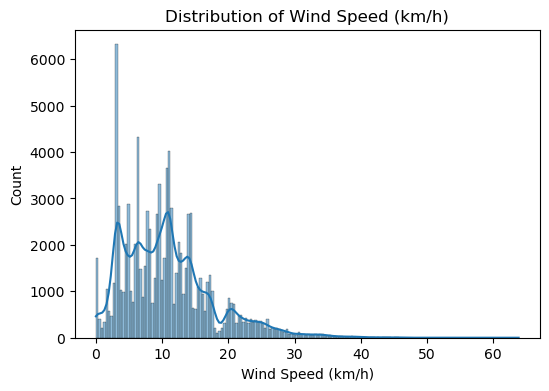

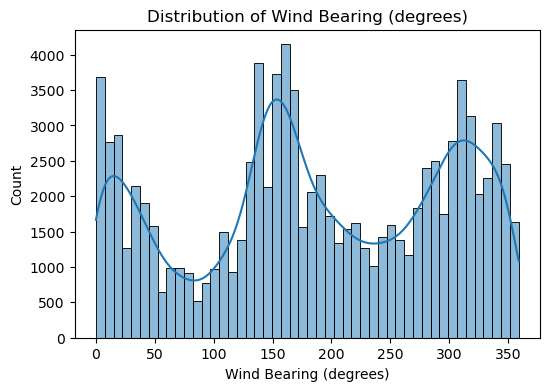

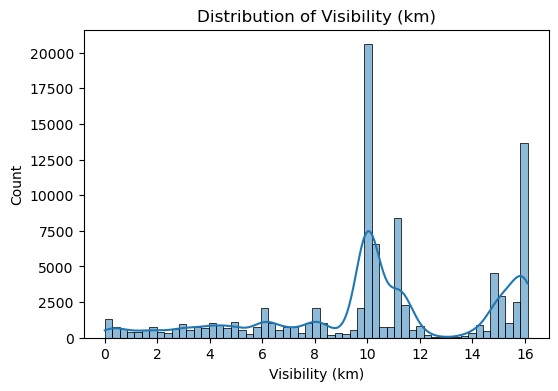

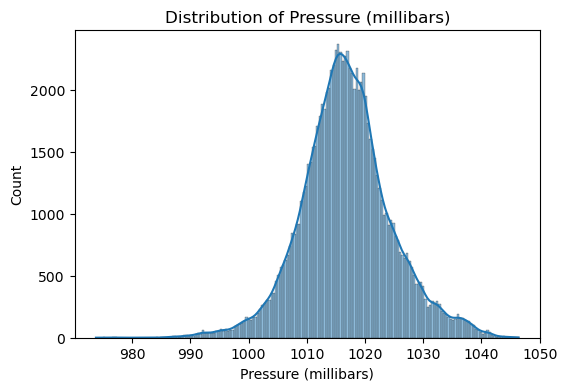

In [27]:
numeric_columns = df.select_dtypes(include=['int64','float64']).columns

for col in numeric_columns:

    plt.figure(figsize=(6,4))
    
    sns.histplot(df[col], kde=True)
    
    plt.title(f"Distribution of {col}")
    
    plt.show()

## Precipitation Type Distribution

This analysis helps determine whether the dataset contains
imbalanced precipitation classes.

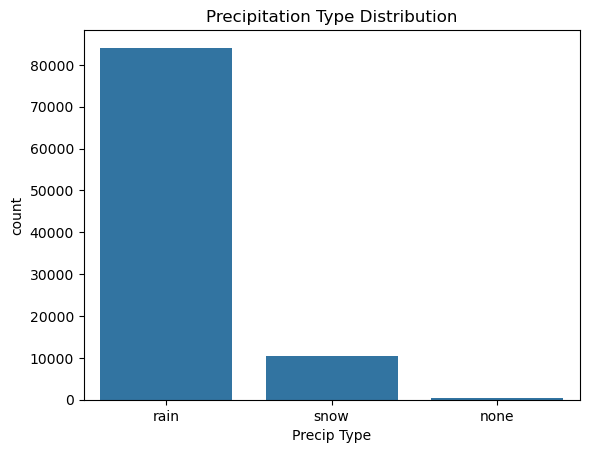

In [28]:
sns.countplot(x="Precip Type", data=df)

plt.title("Precipitation Type Distribution")

plt.show()

In [29]:
df["Precip Type"].value_counts(normalize=True)*100

Precip Type
rain    88.386710
snow    11.069886
none     0.543404
Name: proportion, dtype: float64

#### The distribution of precipitation types shows that **rain dominates the dataset**, while snow and no precipitation occur much less frequently.

#### This indicates a **class imbalance**, which may influence the models to favor predicting the majority class (rain).

## Feature Correlation Matrix

Correlation analysis helps identify relationships between weather variables.

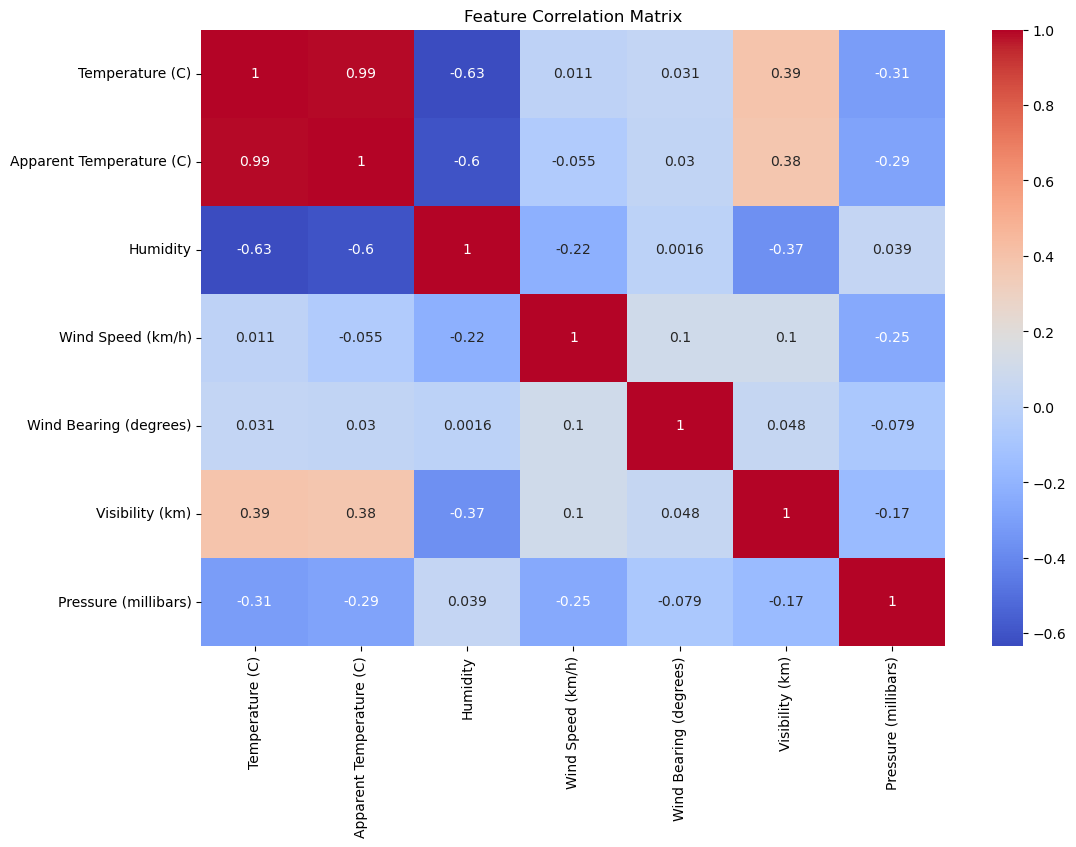

In [30]:
numeric_df = df.select_dtypes(include=['float64','int64'])

plt.figure(figsize=(12,8))

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Matrix")

plt.show()

## Relationship Between Weather Variables and Precipitation

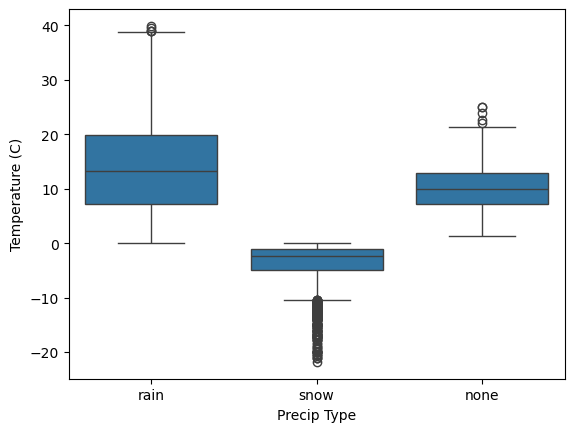

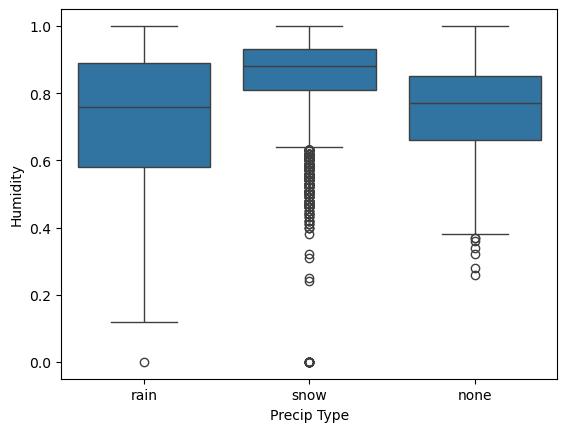

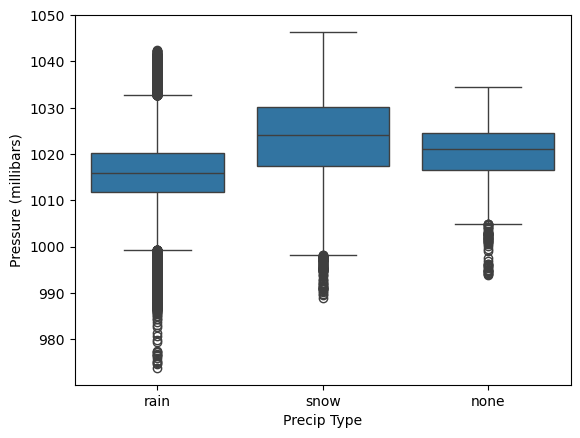

In [31]:
sns.boxplot(x="Precip Type", y="Temperature (C)", data=df)
plt.show()

sns.boxplot(x="Precip Type", y="Humidity", data=df)
plt.show()

sns.boxplot(x="Precip Type", y="Pressure (millibars)", data=df)
plt.show()

## Encoding Precipitation Type

In [32]:
le = LabelEncoder()

df["Precip Type"] = le.fit_transform(df["Precip Type"])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'none': np.int64(0), 'rain': np.int64(1), 'snow': np.int64(2)}


## Define Features and Target

In [33]:
X = df.drop("Precip Type", axis=1)

y = df["Precip Type"]

## Train Test Split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

## Feature Scaling

In [35]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Model Evaluation Function

In [36]:
def evaluate_model(model):

    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test,y_pred))
    
    print("\nConfusion Matrix")
    
    print(confusion_matrix(y_test,y_pred))
    
    print("\nClassification Report")
    
    print(classification_report(y_test,y_pred))

## Machine Learning Models

In [37]:
nb = GaussianNB()
nb.fit(X_train,y_train)
evaluate_model(nb)

dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)
evaluate_model(dt)

rf = RandomForestClassifier()
rf.fit(X_train,y_train)
evaluate_model(rf)

knn = KNeighborsClassifier()
knn.fit(X_train,y_train)
evaluate_model(knn)

Accuracy: 0.9313316750166416

Confusion Matrix
[[   43   107     5]
 [   79 23453  1696]
 [    0    73  3087]]

Classification Report
              precision    recall  f1-score   support

           0       0.35      0.28      0.31       155
           1       0.99      0.93      0.96     25228
           2       0.64      0.98      0.78      3160

    accuracy                           0.93     28543
   macro avg       0.66      0.73      0.68     28543
weighted avg       0.95      0.93      0.94     28543

Accuracy: 0.9980380478576183

Confusion Matrix
[[  129    26     0]
 [   30 25198     0]
 [    0     0  3160]]

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       155
           1       1.00      1.00      1.00     25228
           2       1.00      1.00      1.00      3160

    accuracy                           1.00     28543
   macro avg       0.94      0.94      0.94     28543
weighted avg       1.00  

## Cross Validation

Cross validation helps evaluate model stability across different training splits.

In [38]:
scores = cross_val_score(rf, X, y, cv=5)

print("Cross Validation Scores:", scores)

print("Average Score:", scores.mean())

Cross Validation Scores: [0.99453466 0.99490225 0.97966155 0.99537524 0.68409712]
Average Score: 0.9297141629739581


#### The lower score in one fold suggests that the model performance may vary depending on the data split. This could be due to class imbalance or variations in precipitation patterns within the dataset.

## Feature Importance

Random Forest feature importance shows which weather variables most strongly
influence precipitation predictions.

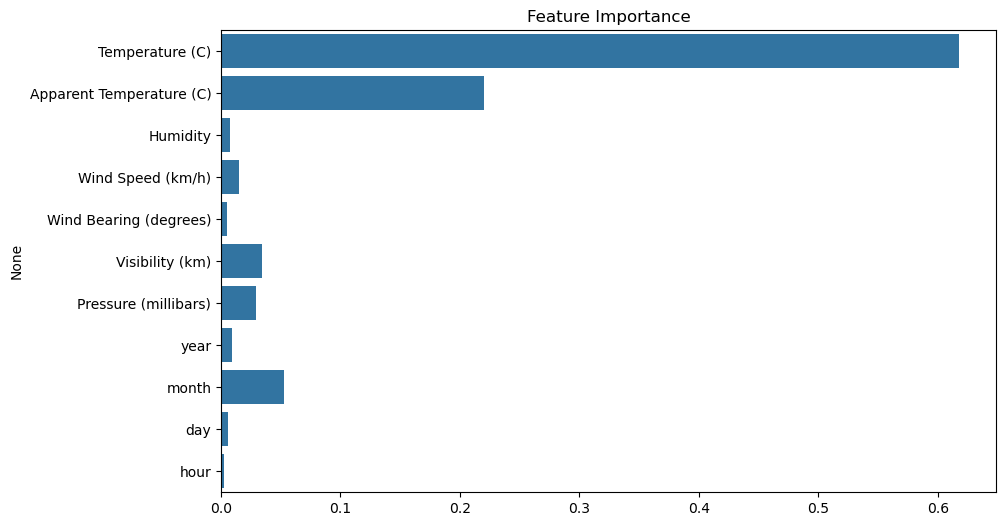

In [39]:
importance = rf.feature_importances_

features = X.columns

plt.figure(figsize=(10,6))

sns.barplot(x=importance, y=features)

plt.title("Feature Importance")

plt.show()

#### The feature importance results show that **Temperature (C)** is the most influential variable for predicting precipitation type, followed by **Apparent Temperature (C)**.

#### This is expected because temperature plays a key role in determining whether precipitation occurs as rain or snow. Other variables such as month, pressure, visibility, and wind-related features contribute less to the model’s predictions.

## Best Performing Model

Among all tested models, the **Random Forest classifier**
achieved the most stable and highest predictive performance.

Random Forest is particularly effective for tabular data because it:

• Handles nonlinear relationships  
• Reduces overfitting through ensemble learning  
• Provides feature importance insights

## Limitations

• The dataset contains more observations with no precipitation, which may bias the model toward predicting the majority class.

• The dataset includes a limited number of weather variables, so some important atmospheric factors may not be captured.

• The models treat each observation independently and do not consider time-series weather patterns.

• The models were trained using default parameters and could be improved with hyperparameter tuning.

## Conclusion

This project explored historical weather data to predict precipitation type
using machine learning techniques.

Key Findings:

• Humidity and temperature are the strongest predictors of precipitation  
• Ensemble models such as Random Forest perform best on this dataset  
• Feature importance analysis provides insight into atmospheric patterns

The model demonstrates how machine learning can be applied to
weather forecasting problems using historical environmental data.